# AI-powered Cloud Masking
- Machine learning was used more specifically `Random Forest` to detect clouds using binary masks

## Setup Environment  

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

from utils import (
    image_mask_to_array,
    image_mask_to_df,
    plot_image_mask_pred,
    build_training_dataframe_dask,
    read_and_plot,
    save_model_and_print_params,
    per_band_minmax,
    plot_image_and_mask
)
from loading import load_full_dataset, load_model, load_image_and_mask
from evaluation import evaluate_dice_score
from const import IMAGES_PATH, MASKS_PATH

## Loading Dataset and Splitting

In [34]:
images, masks = load_full_dataset(IMAGES_PATH, MASKS_PATH)
images.shape, masks.shape

100%|██████████| 9/9 [00:00<00:00, 64.68it/s]


((9, 256, 256, 4), (9, 256, 256))

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

In [5]:
df_train = build_training_dataframe_dask(x_train, y_train)
df_train.shape

(458752, 7)

## Exploratory Data Analysis 

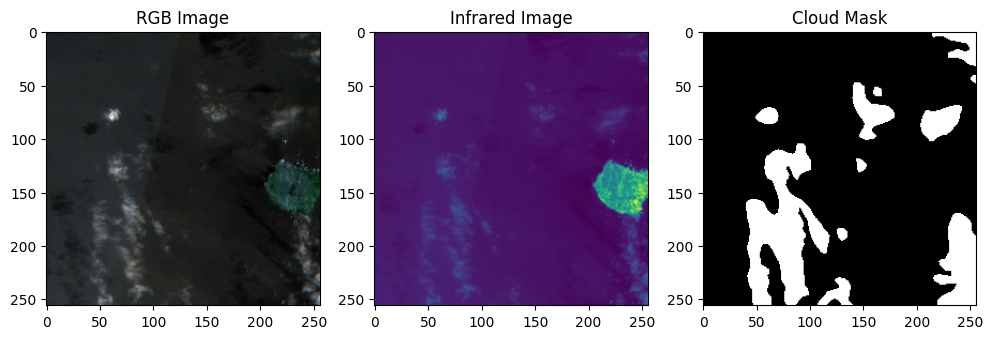

array([0, 1], dtype=uint8)

In [14]:
image_path, mask_path = read_and_plot(104666)

image, mask = load_image_and_mask(image_path, mask_path)
image = per_band_minmax(image)

plot_image_and_mask(image, mask)
np.unique(mask)

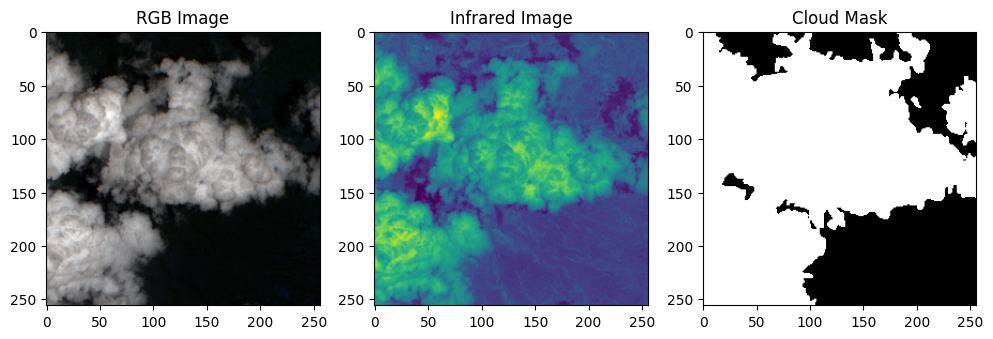

array([0, 1], dtype=uint8)

In [ ]:
image_path, mask_path = read_and_plot(119627)

image, mask = load_image_and_mask(image_path, mask_path)
image = per_band_minmax(image)

plot_image_and_mask(image, mask)
np.unique(mask)

In [15]:
image_mask_to_df(x_train[0], y_train[0]).shape

(65536, 7)

In [14]:
# correlation_matrix_pca = df_train.corr()

# # Plot the correlation matrix
# plt.figure(figsize=(10, 8))
# sns.heatmap(correlation_matrix_pca, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
# plt.title('Correlation Matrix of PCA-transformed Features')
# plt.show()

In [16]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 458752 entries, 0 to 65535
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   r            458752 non-null  float32
 1   g            458752 non-null  float32
 2   b            458752 non-null  float32
 3   infrared     458752 non-null  float32
 4   ndsi         458752 non-null  float32
 5   cloud_index  458752 non-null  float32
 6   class        458752 non-null  bool   
dtypes: bool(1), float32(6)
memory usage: 14.4 MB


class
False    322959
True     135793
Name: count, dtype: int64


<Axes: xlabel='class'>

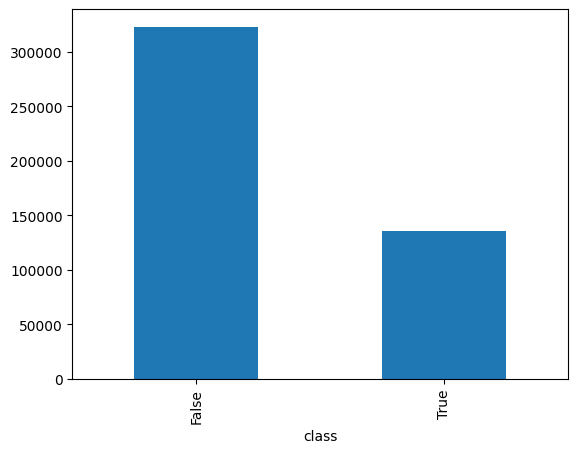

In [17]:
print(df_train["class"].value_counts())
df_train["class"].value_counts().plot(kind="bar")

## Building Model

In [18]:
X = df_train.drop(columns=["class"])
y = df_train["class"]

In [19]:
# X = x_train.reshape(-1, 4).astype('float32')  # Flatten the images to (n_samples, 4)
# y =  y_train.reshape(-1).astype('float32')

In [20]:
pca = PCA(n_components=X.shape[1])
model = make_pipeline(
    pca,
    RandomForestClassifier(
        n_estimators=100, max_depth=15, random_state=42, n_jobs=-1  # number of trees
    ),
)
X.shape[1]

6

In [21]:
model.fit(X, y)

Pipeline(steps=[('pca', PCA(n_components=6)),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=15, n_jobs=-1,
                                        random_state=42))])

## Exploring Final Model

In [22]:
save_model_and_print_params(model)

Model saved to random_forest_model.pkl

Model Parameters:

Parameters for pca:
  copy: True
  iterated_power: auto
  n_components: 6
  n_oversamples: 10
  power_iteration_normalizer: auto
  random_state: None
  svd_solver: auto
  tol: 0.0
  whiten: False

Parameters for randomforestclassifier:
  bootstrap: True
  ccp_alpha: 0.0
  class_weight: None
  criterion: gini
  max_depth: 15
  max_features: sqrt
  max_leaf_nodes: None
  max_samples: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 2
  min_weight_fraction_leaf: 0.0
  monotonic_cst: None
  n_estimators: 100
  n_jobs: -1
  oob_score: False
  random_state: 42
  verbose: 0
  warm_start: False


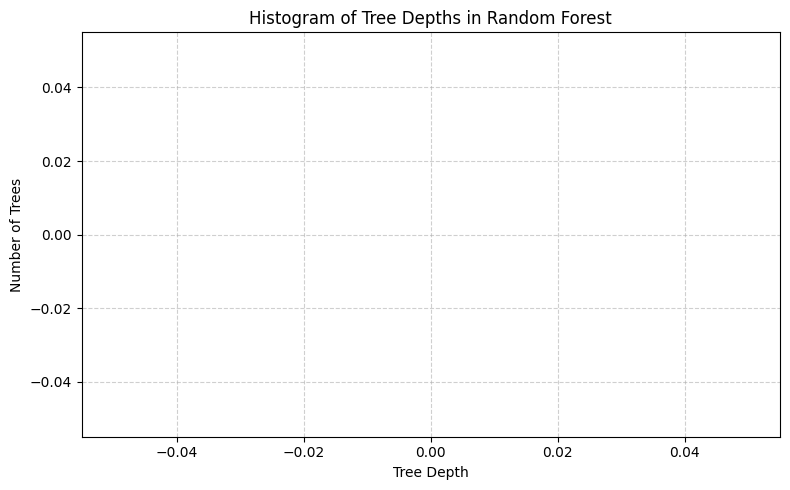

In [23]:
# Access trained RandomForestClassifier from pipeline
rf = model.named_steps["randomforestclassifier"]

# Get all tree depths
depths = [estimator.tree_.max_depth for estimator in rf.estimators_]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(
    depths, bins=range(min(depths), max(depths) + 1), color="skyblue", edgecolor="black"
)
plt.title("Histogram of Tree Depths in Random Forest")
plt.xlabel("Tree Depth")
plt.ylabel("Number of Trees")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Feature Importance')

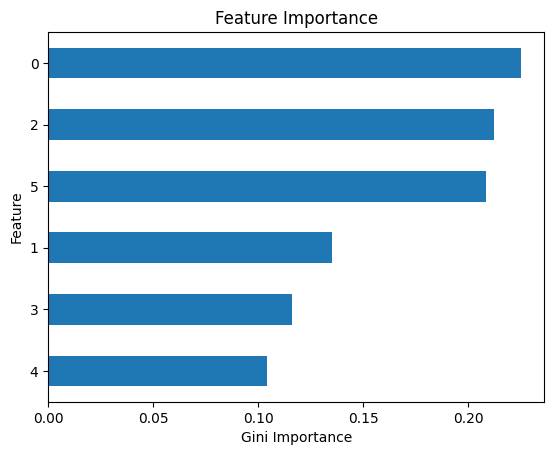

In [24]:
# Extract importances from model
importances = model.named_steps["randomforestclassifier"].feature_importances_
# Create a series with feature names and importances
feat_imp = pd.Series(importances)
# Plot 10 most important features
feat_imp.sort_values().tail(10).plot(kind="barh")
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

In [25]:
# Assuming pca is your fitted PCA object
pca_components = pd.DataFrame(pca.components_, columns=X.columns)

print(pca_components.head())

          r         g         b  infrared      ndsi  cloud_index
0  0.000010  0.000007  0.000010 -0.000027  0.000127     1.000000
1  0.333789  0.312597  0.327186  0.013378  0.826824    -0.000113
2  0.389870  0.401661  0.362354  0.584669 -0.462095     0.000065
3 -0.296506 -0.088948 -0.440993  0.781249  0.315195    -0.000011
4 -0.605690 -0.244735  0.742064  0.144567  0.041059    -0.000001


In [26]:
importance_scores = pca_components.abs().sum(axis=0)
print(importance_scores.sort_values())

cloud_index    1.000192
infrared       1.687396
ndsi           1.687682
g              1.868402
b              2.001119
r              2.156723
dtype: float32


## Evaluation 

In [53]:
model = load_model("./random_forest_model8852.pkl")

Model loaded from ./random_forest_model8852.pkl


In [27]:
score = evaluate_dice_score(model, image_mask_to_array(images), masks)
print(f"Accuracy: {score:.4f}")

c:\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature nam

Accuracy: 0.7836


c:\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


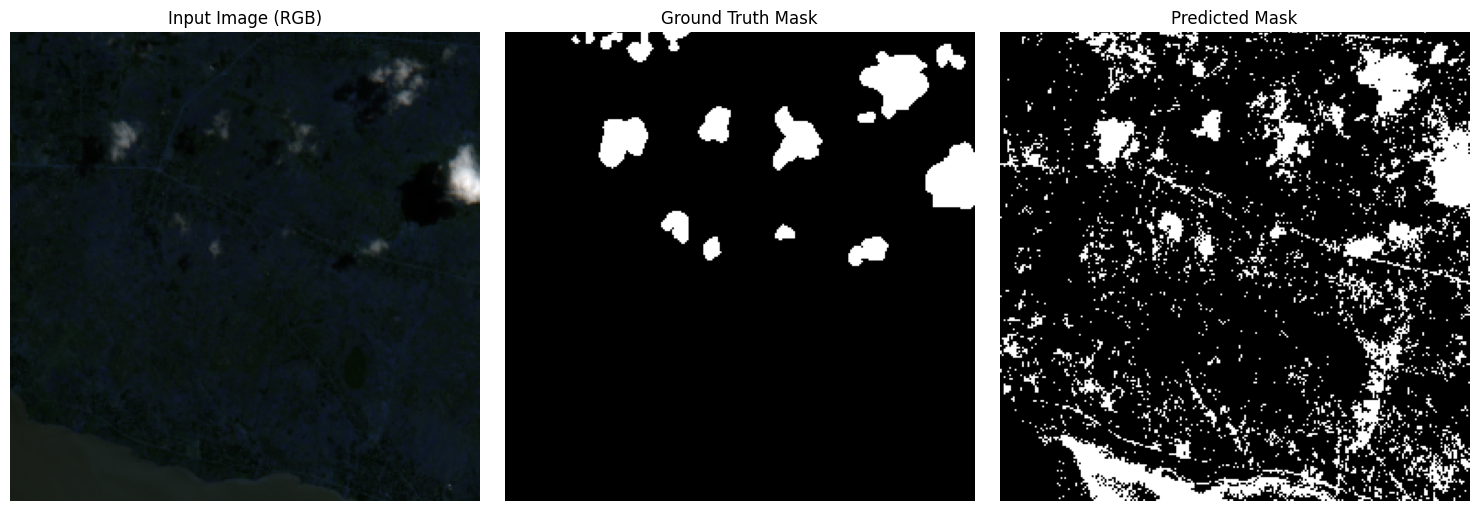

[0 1]


In [33]:
plot_image_mask_pred(model, image_mask_to_array(x_test), y_test, 1)